In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df=pd.read_excel("/workspaces/Effector-Structure-Prediction/80_fungal_effector_structures_V9.xlsx", sheet_name="Structures", skiprows=5)
df.columns = df.columns.str.strip()

In [24]:
print(df.columns.tolist())

['Structural family (inferred from La Naour Vernet et al. (2025))', 'PDB_ID', 'How many protein identities in crystal structure', 'Chain', 'PDB_ID_2', 'Annotation', 'Organism', 'Effector', 'Method', 'Resolution', 'Found in', 'Resolved by', 'Deposition_date', 'TM_score_crystal', 'TM_score_predicted', 'RMSD', 'Aligned_length', 'Seq_ID', 'Predicted_length', 'Experimental_length', 'Coverage', 'TM_score_crystal3', 'TM_score_predicted4', 'RMSD5', 'Aligned_length6', 'Seq_ID7', 'Predicted_length8', 'Experimental_length9', 'Coverage2', 'TM_score_crystal2', 'TM_score_predicted3', 'RMSD4', 'Aligned_length5', 'Seq_ID6', 'Predicted_length7', 'Experimental_length8', 'Coverage3']


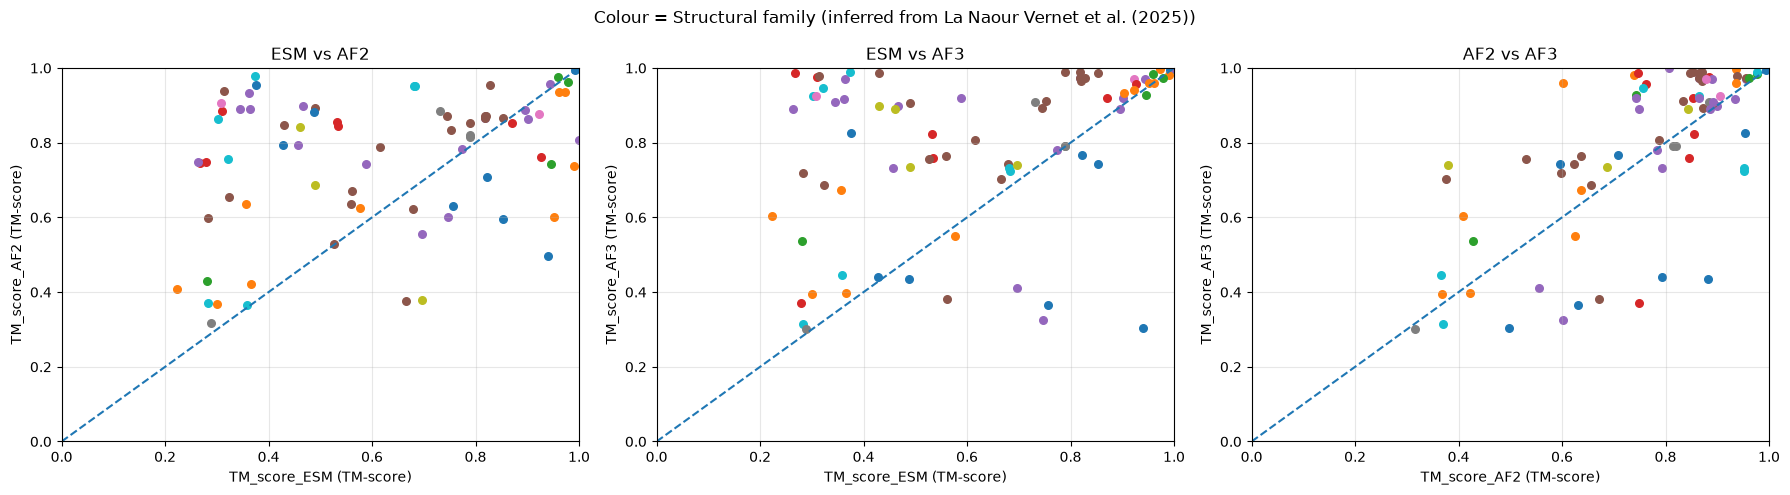

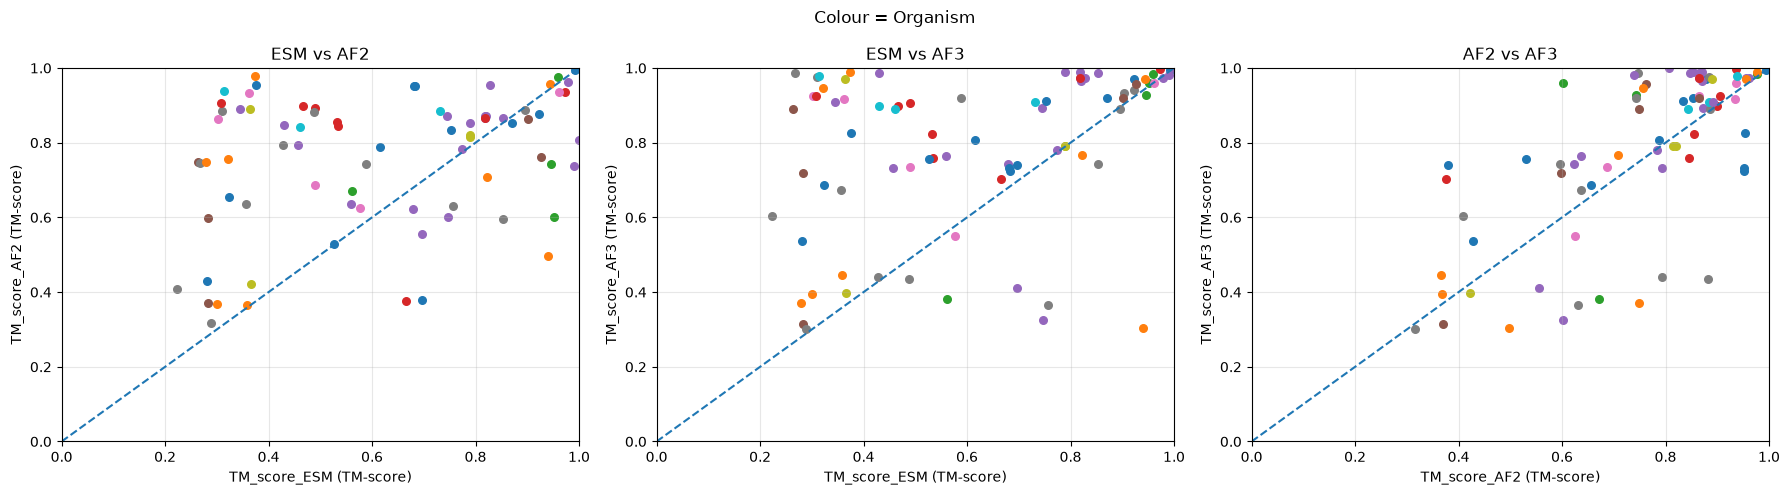

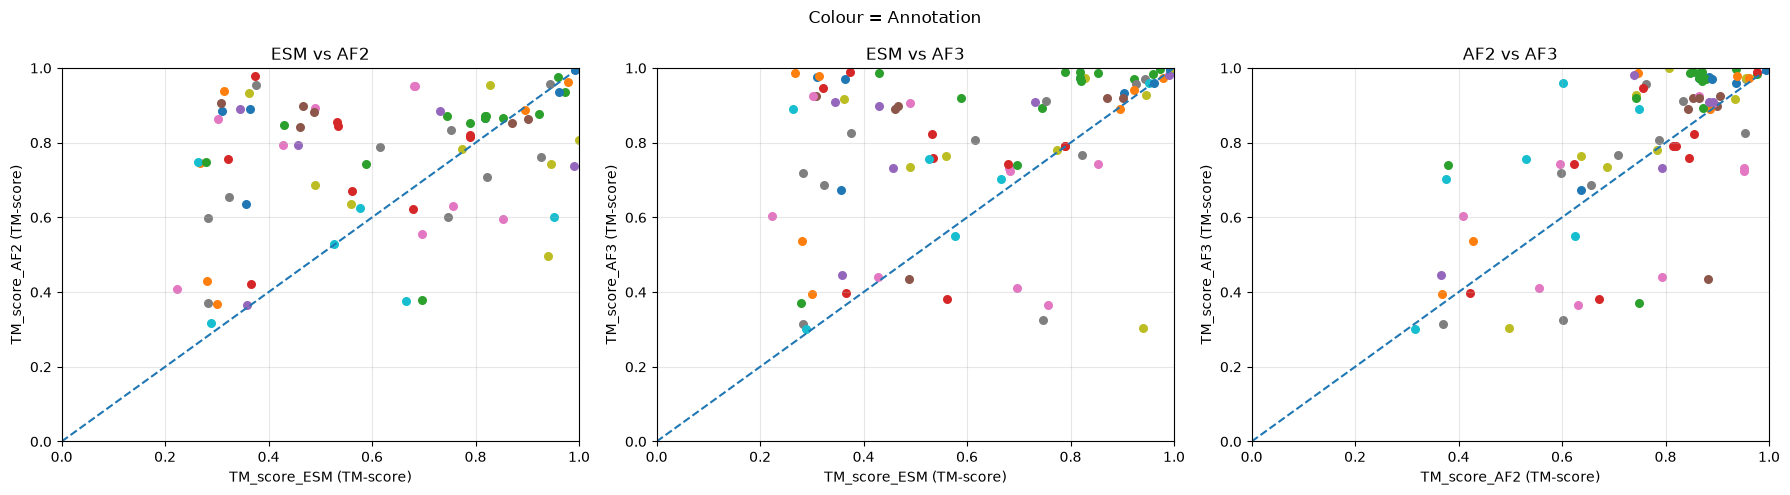

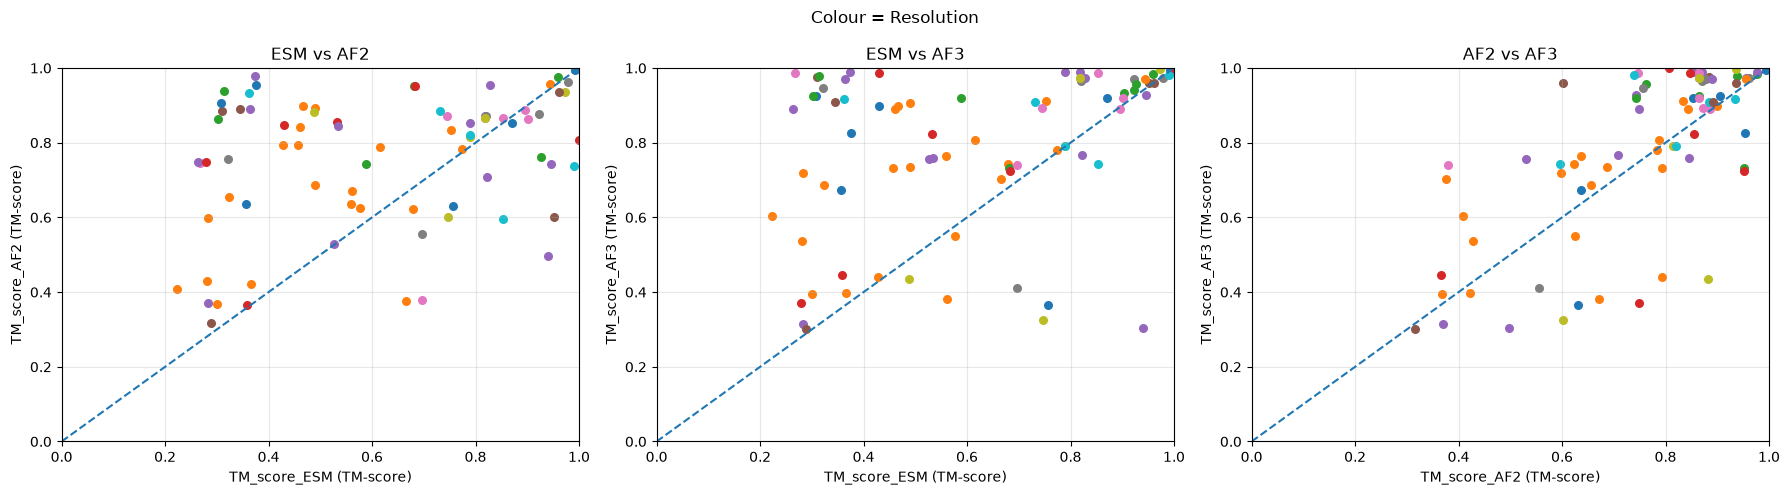

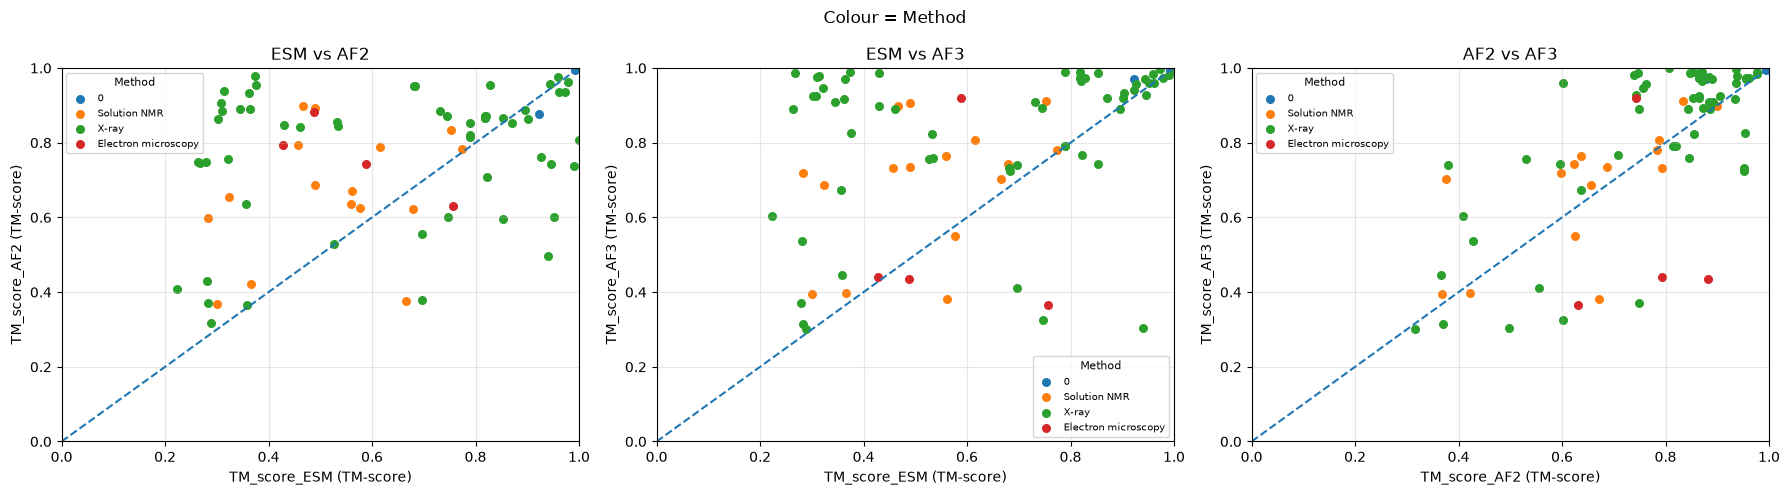

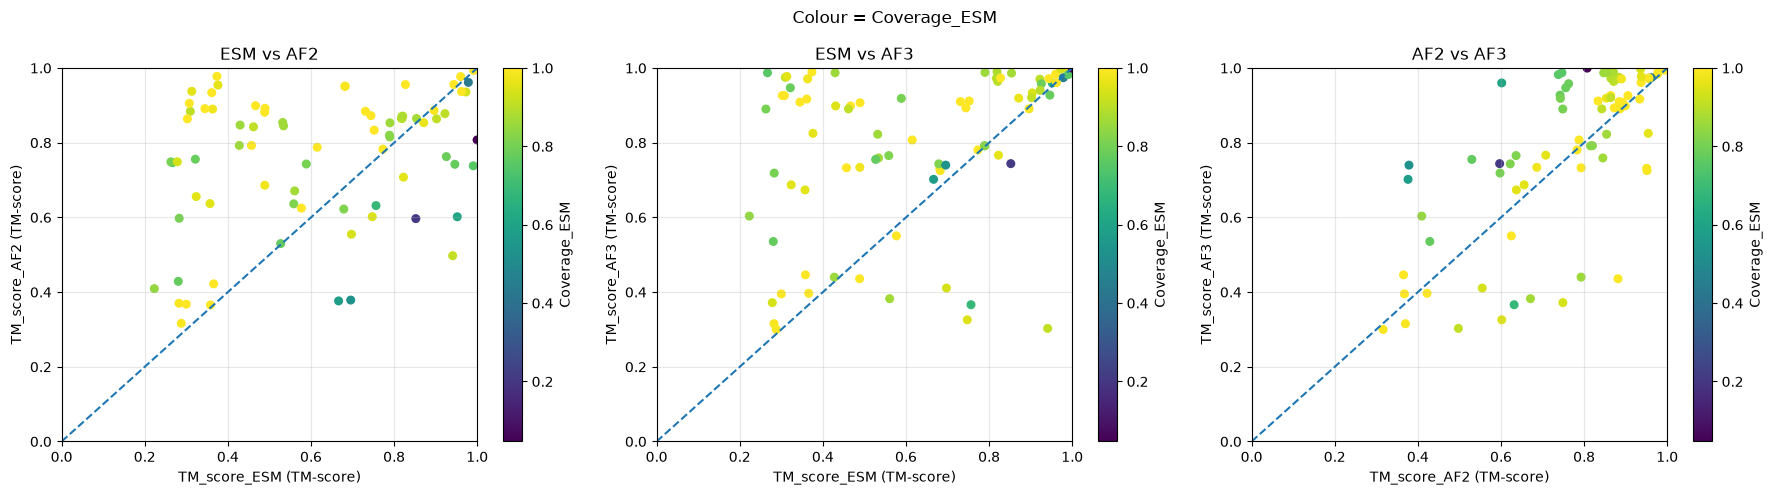

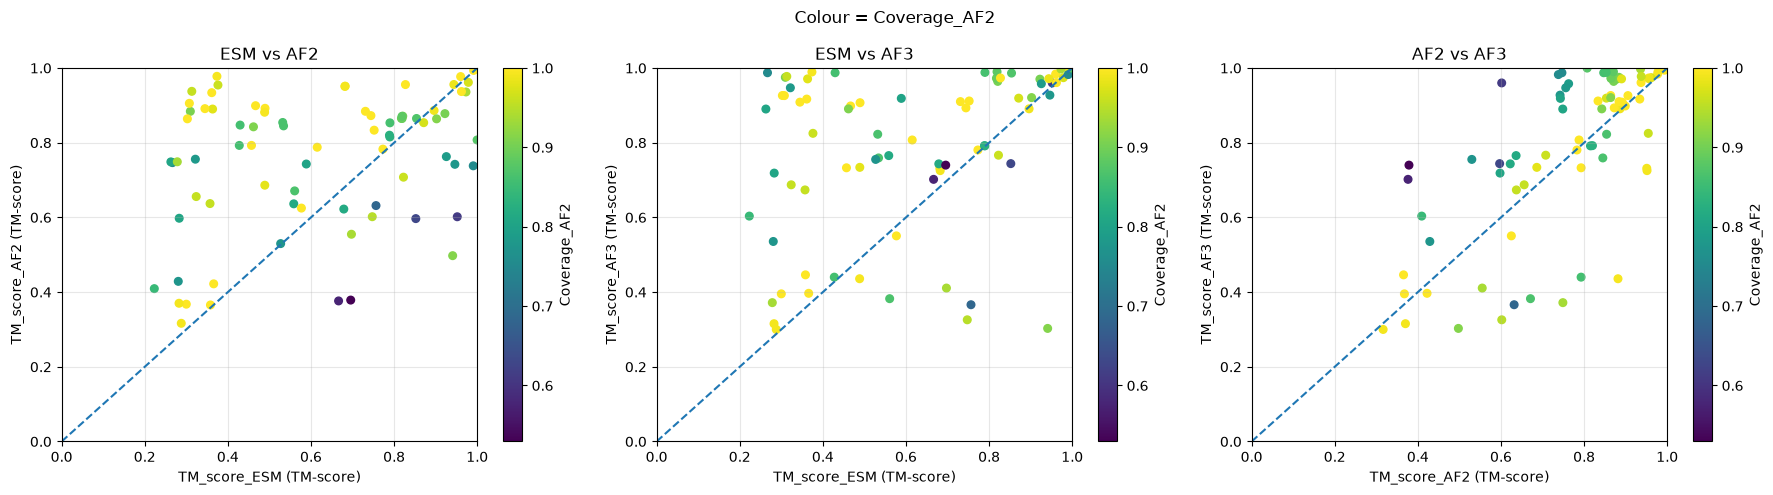

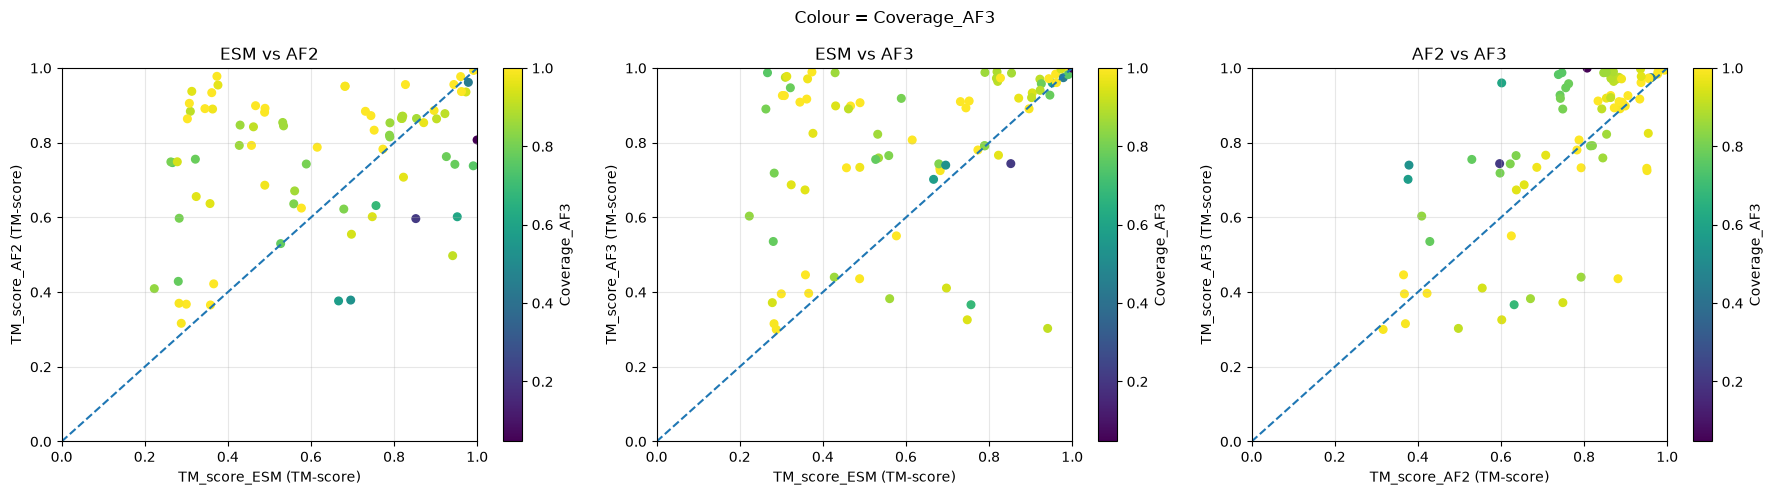

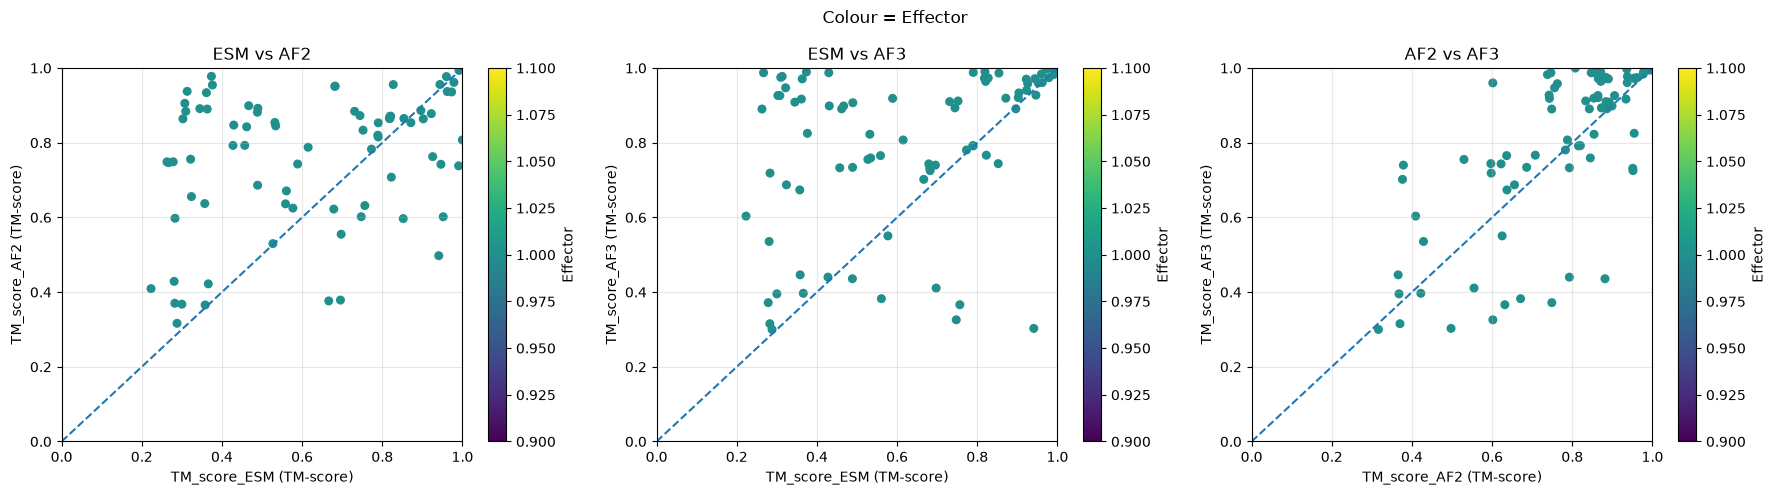

In [28]:
df = df.rename(columns={
    "TM_score_predicted": "TM_score_ESM",
    "TM_score_predicted4": "TM_score_AF2",
    "TM_score_predicted3": "TM_score_AF3",
    "TM_score_crystal": "TM_score_crystal_ESM",
    "TM_score_crystal3": "TM_score_crystal_AF2",
    "TM_score_crystal2": "TM_score_crystal_AF3",
    "Predicted_length": "Length_ESM",
    "Predicted_length8": "Length_AF2",
    "Predicted_length7": "Length_AF3",
    "Coverage": "Coverage_ESM",
    "Coverage2": "Coverage_AF2",
    "Coverage3": "Coverage_AF3",
})

comparisons = [
    ("TM_score_ESM", "TM_score_AF2", "ESM vs AF2"),
    ("TM_score_ESM", "TM_score_AF3", "ESM vs AF3"),
    ("TM_score_AF2", "TM_score_AF3", "AF2 vs AF3"),
]

metadata = [
    "Structural family (inferred from La Naour Vernet et al. (2025))",
    "Organism",
    "Annotation",
    "Resolution",
    "Method",
    "Coverage_ESM",
    "Coverage_AF2",
    "Coverage_AF3",
    "Effector",
]

for colour_column in metadata:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        if pd.api.types.is_numeric_dtype(df[colour_column]):

            scatter = ax.scatter(
                df[xcol],
                df[ycol],
                c=df[colour_column],
                s=30
            )

            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label(colour_column)
            
        else:

            categories = df[colour_column].astype(str).unique()

            for category in categories:

                subset = df[df[colour_column].astype(str) == category]

                ax.scatter(
                    subset[xcol],
                    subset[ycol],
                    label=category,
                    s=30
                )

            # only show legend if there are not too many categories
            if len(categories) <= 10:
                ax.legend(
                    title=colour_column,
                    fontsize=7,
                    title_fontsize=8
                )

        ax.plot([0, 1], [0, 1], "--")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

        ax.set_xlabel(f"{xcol} (TM-score)")
        ax.set_ylabel(f"{ycol} (TM-score)")
        ax.set_title(title)

    fig.suptitle(f"Colour = {colour_column}")
    plt.tight_layout()
    plt.show()
    plt.close()